# Install Dependencies

In [1]:
!pip install python-docx matplotlib seaborn joblib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 14.4 MB/s eta 0:00:00


# Import Libraries

In [2]:
import os
import json
import numpy as np
import pandas as pd
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from docx import Document
import joblib

In [3]:
from google.colab import drive
drive.mount('/users/')

Mounted at /users/


# Define Dataset Paths

In [4]:
BASE = "/users/"

DATASETS = {
    "CIC_IIoT_2025": os.path.join(BASE, "CIC_IIoT_2025"),
    "CIC_BCCC_NRC_IoMT_2024": os.path.join(BASE, "CIC_BCCC_NRC_IoMT_2024"),
    "CSE_CIC_IDS2018": os.path.join(BASE, "CSE_CIC_IDS2018"),
    "FALCON_ID_Combined": os.path.join(BASE, "Combined"),
}

DATASETS

{'CIC_IIoT_2025': '/users/',
 'CIC_BCCC_NRC_IoMT_2024': '/users/',
 'CSE_CIC_IDS2018': '/users/',
 'FALCON_ID_Combined': '/users/'}

# Utility Functions for Loading

In [5]:
def load_latent_split(dataset_dir):
    X_train = np.load(os.path.join(dataset_dir, "train_latent.npy"))
    X_val   = np.load(os.path.join(dataset_dir, "val_latent.npy"))
    X_test  = np.load(os.path.join(dataset_dir, "test_latent.npy"))

    y_train = np.load(os.path.join(dataset_dir, "y_train.npy"))
    y_val   = np.load(os.path.join(dataset_dir, "y_val.npy"))
    y_test  = np.load(os.path.join(dataset_dir, "y_test.npy"))

    return X_train, X_val, X_test, y_train, y_val, y_test


def load_label_encoder(dataset_dir):
    p = os.path.join(dataset_dir, "label_encoder.pkl")
    if os.path.exists(p):
        return joblib.load(p)
    return None


def load_json_summary(dataset_dir):
    summary_path = os.path.join(dataset_dir, "preprocessing_summary.json")
    if os.path.exists(summary_path):
        with open(summary_path, "r") as f:
            return json.load(f)
    return None

# Load All Datasets

In [7]:
all_data = {}

for name, path in DATASETS.items():
    print(f"\n📂 Loading dataset: {name}")

    if name == "FALCON_ID_Combined":
        # Combined dataset uses different naming
        X_train = np.load(os.path.join(path, "combined_train_latent.npy"))
        X_val   = np.load(os.path.join(path, "combined_val_latent.npy"))
        X_test  = np.load(os.path.join(path, "combined_test_latent.npy"))

        y_train = np.load(os.path.join(path, "combined_y_train.npy"))
        y_val   = np.load(os.path.join(path, "combined_y_val.npy"))
        y_test  = np.load(os.path.join(path, "combined_y_test.npy"))

        encoder = None
        summary = json.load(open(os.path.join(path, "combined_summary.json")))

    else:
        X_train, X_val, X_test, y_train, y_val, y_test = load_latent_split(path)
        encoder = load_label_encoder(path)
        summary = load_json_summary(path)

    all_data[name] = {
        "X_train": X_train, "X_val": X_val, "X_test": X_test,
        "y_train": y_train, "y_val": y_val, "y_test": y_test,
        "encoder": encoder,
        "summary": summary,
    }

    print(f"✔ Loaded. Train shape = {X_train.shape}, Classes = {len(np.unique(y_train))}")



📂 Loading dataset: CIC_IIoT_2025
✔ Loaded. Train shape = (29424, 64), Classes = 7

📂 Loading dataset: CIC_BCCC_NRC_IoMT_2024
✔ Loaded. Train shape = (2369719, 64), Classes = 15

📂 Loading dataset: CSE_CIC_IDS2018
✔ Loaded. Train shape = (6737603, 64), Classes = 15

📂 Loading dataset: FALCON_ID_Combined
✔ Loaded. Train shape = (9136746, 64), Classes = 37


# Simple Summary Table

In [8]:
report = []

for name, d in all_data.items():
    report.append([
        name,
        d["X_train"].shape[0],
        d["X_val"].shape[0],
        d["X_test"].shape[0],
        len(np.unique(d["y_train"]))
    ])

pd.DataFrame(report, columns=["Dataset", "Train", "Val", "Test", "Classes"])

,Dataset,Train,Val,Test,Classes
0,CIC_IIoT_2025,29424,6305,6306,7
1,CIC_BCCC_NRC_IoMT_2024,2369719,507797,507797,15
2,CSE_CIC_IDS2018,6737603,1443772,1443773,15
3,FALCON_ID_Combined,9136746,1957874,1957876,37


# Class Distribution Visualizations

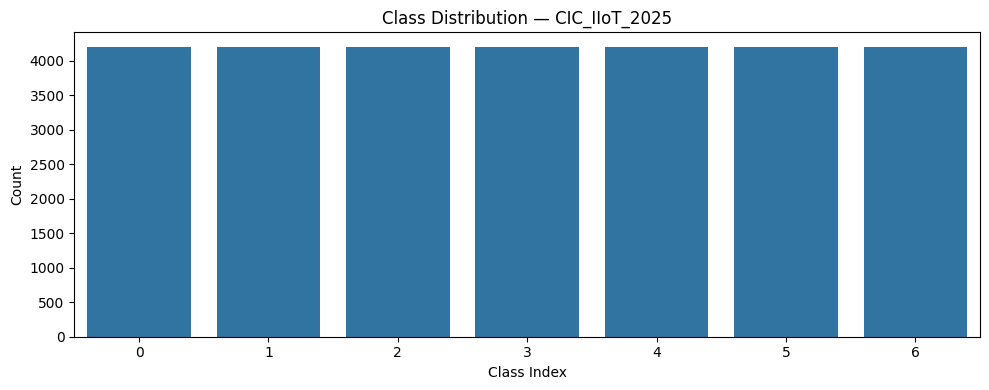

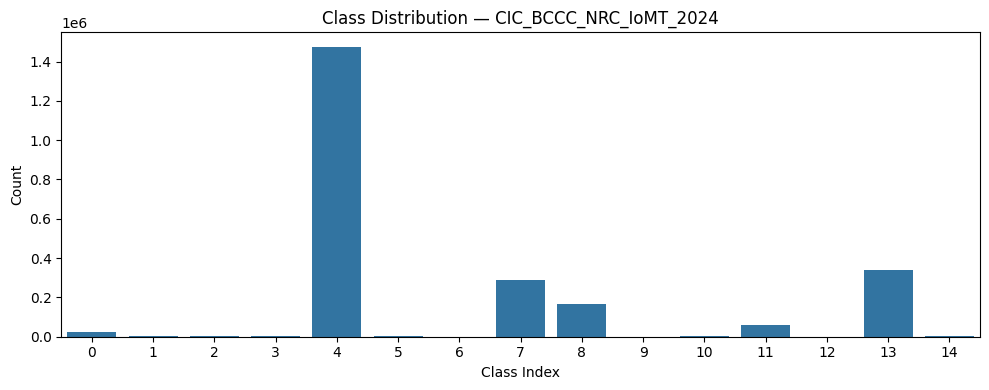

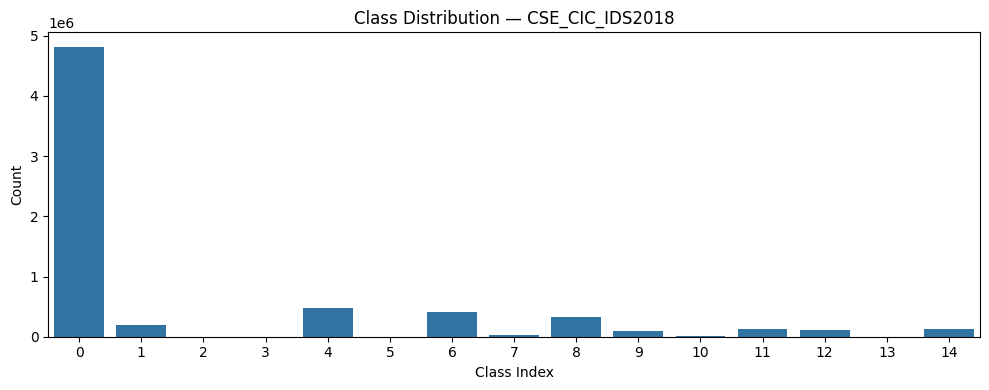

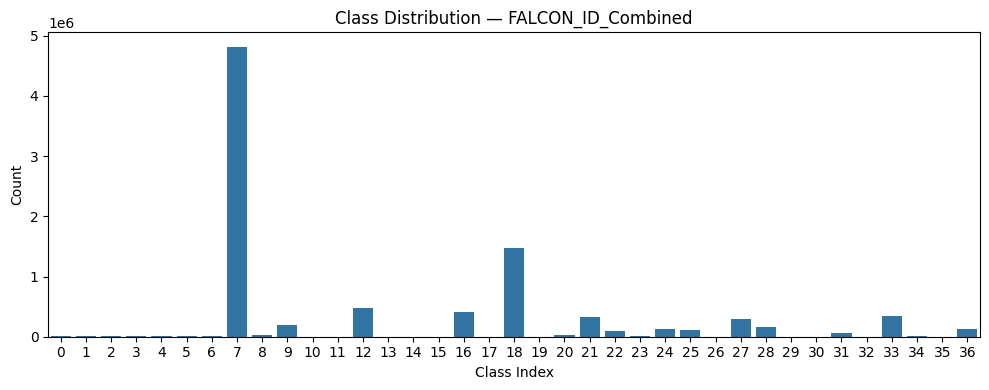

In [9]:
for name, d in all_data.items():
    y = d["y_train"]
    counter = Counter(y.tolist())

    plt.figure(figsize=(10, 4))
    sns.barplot(x=list(counter.keys()), y=list(counter.values()))
    plt.title(f"Class Distribution — {name}")
    plt.xlabel("Class Index")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


# Load Client Partitions (Non-IID Simulation)

In [10]:
def load_client_metadata(dataset_dir):
    meta_path = os.path.join(dataset_dir, "clients_non_iid", "clients_metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path, "r") as f:
            return json.load(f)
    return None

client_info = {}
for name, path in DATASETS.items():
    meta = load_client_metadata(path)
    client_info[name] = meta
    print(f"{name} → Clients found: {meta['n_clients'] if meta else 0}")

CIC_IIoT_2025 → Clients found: 10
CIC_BCCC_NRC_IoMT_2024 → Clients found: 20
CSE_CIC_IDS2018 → Clients found: 20
FALCON_ID_Combined → Clients found: 30


# Visualize Client Distribution


📌 Client Distribution for CIC_IIoT_2025


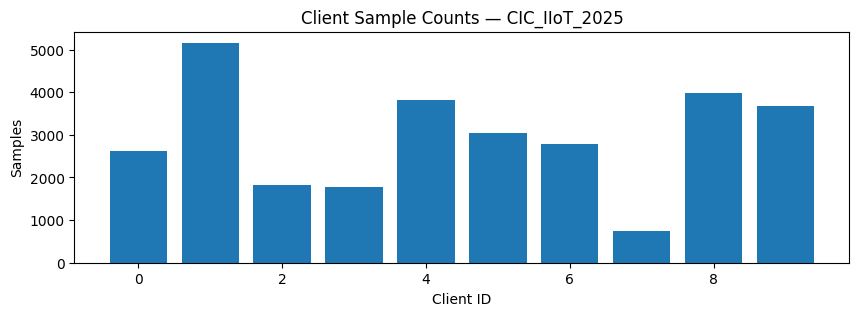


📌 Client Distribution for CIC_BCCC_NRC_IoMT_2024


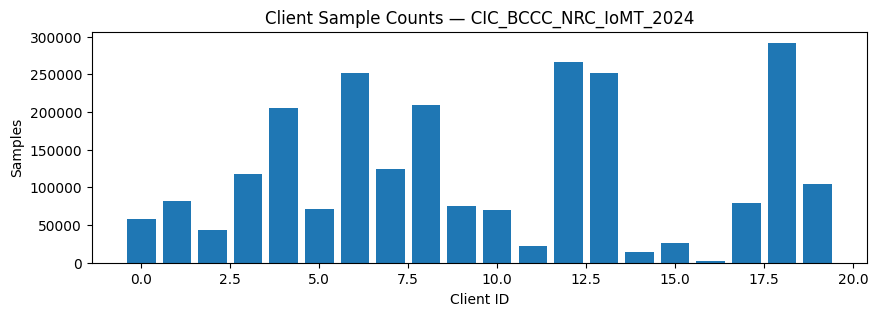


📌 Client Distribution for CSE_CIC_IDS2018


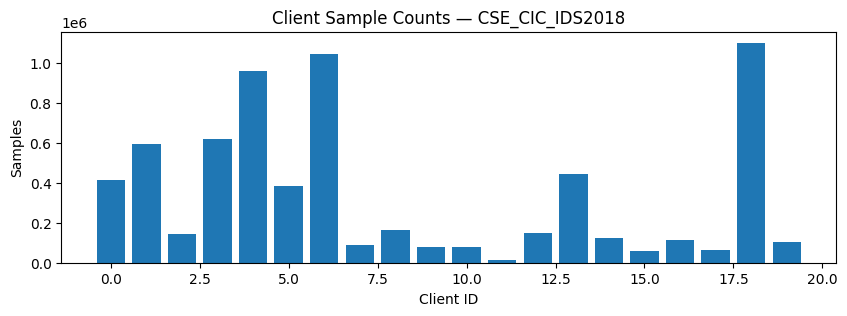


📌 Client Distribution for FALCON_ID_Combined


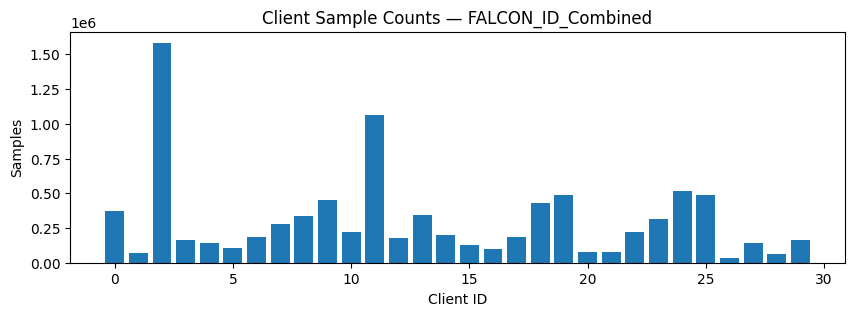

In [11]:
for name, meta in client_info.items():
    if meta is None:
        continue

    print(f"\n📌 Client Distribution for {name}")

    samples = [c["num_samples"] for c in meta["clients"]]

    plt.figure(figsize=(10, 3))
    plt.bar(range(len(samples)), samples)
    plt.title(f"Client Sample Counts — {name}")
    plt.xlabel("Client ID")
    plt.ylabel("Samples")
    plt.show()

# Validate Shape & Integrity

In [12]:
for name, d in all_data.items():
    print(f"\n🔍 Checking dataset integrity: {name}")

    X_train, y_train = d["X_train"], d["y_train"]
    X_val, y_val     = d["X_val"], d["y_val"]
    X_test, y_test   = d["X_test"], d["y_test"]

    print("Train X:", X_train.shape, "Y:", y_train.shape)
    print("Val   X:", X_val.shape, "Y:", y_val.shape)
    print("Test  X:", X_test.shape, "Y:", y_test.shape)

    assert X_train.shape[0] == y_train.shape[0], "Mismatch in training set"
    assert X_val.shape[0] == y_val.shape[0], "Mismatch in validation set"
    assert X_test.shape[0] == y_test.shape[0], "Mismatch in test set"

print("\n✔ All datasets validated successfully.")


🔍 Checking dataset integrity: CIC_IIoT_2025
Train X: (29424, 64) Y: (29424,)
Val   X: (6305, 64) Y: (6305,)
Test  X: (6306, 64) Y: (6306,)

🔍 Checking dataset integrity: CIC_BCCC_NRC_IoMT_2024
Train X: (2369719, 64) Y: (2369719,)
Val   X: (507797, 64) Y: (507797,)
Test  X: (507797, 64) Y: (507797,)

🔍 Checking dataset integrity: CSE_CIC_IDS2018
Train X: (6737603, 64) Y: (6737603,)
Val   X: (1443772, 64) Y: (1443772,)
Test  X: (1443773, 64) Y: (1443773,)

🔍 Checking dataset integrity: FALCON_ID_Combined
Train X: (9136746, 64) Y: (9136746,)
Val   X: (1957874, 64) Y: (1957874,)
Test  X: (1957876, 64) Y: (1957876,)

✔ All datasets validated successfully.


# Compare Feature Dimensions Between Datasets

In [13]:
dims = {
    name: d["X_train"].shape[1]
    for name, d in all_data.items()
}

pd.DataFrame.from_dict(dims, orient="index", columns=["Feature Dim"])


,Feature Dim
CIC_IIoT_2025,64
CIC_BCCC_NRC_IoMT_2024,64
CSE_CIC_IDS2018,64
FALCON_ID_Combined,64


# Unified Summary Report

In [14]:
summary_report = {}

for name, data in all_data.items():
    y = data["y_train"]
    counts = Counter(y.tolist())

    summary_report[name] = {
        "samples_train": data["X_train"].shape[0],
        "samples_val": data["X_val"].shape[0],
        "samples_test": data["X_test"].shape[0],
        "latent_dim": data["X_train"].shape[1],
        "num_classes": len(counts),
        "top_classes": dict(counts.most_common(5)),
    }

summary_report

{'CIC_IIoT_2025': {'samples_train': 29424,
  'samples_val': 6305,
  'samples_test': 6306,
  'latent_dim': 64,
  'num_classes': 7,
  'top_classes': {1: 4204, 5: 4204, 0: 4204, 3: 4203, 4: 4203}},
 'CIC_BCCC_NRC_IoMT_2024': {'samples_train': 2369719,
  'samples_val': 507797,
  'samples_test': 507797,
  'latent_dim': 64,
  'num_classes': 15,
  'top_classes': {4: 1474841, 13: 339865, 7: 289739, 8: 166622, 11: 59722}},
 'CSE_CIC_IDS2018': {'samples_train': 6737603,
  'samples_val': 1443772,
  'samples_test': 1443773,
  'latent_dim': 64,
  'num_classes': 15,
  'top_classes': {0: 4813839, 4: 480208, 6: 403334, 8: 323338, 1: 200334}},
 'FALCON_ID_Combined': {'samples_train': 9136746,
  'samples_val': 1957874,
  'samples_test': 1957876,
  'latent_dim': 64,
  'num_classes': 37,
  'top_classes': {7: 4813839,
   18: 1474841,
   12: 480208,
   16: 403334,
   33: 339865}}}